<a href="https://colab.research.google.com/github/andlatorre/HIDROINFORMATICA_PARCIAL/blob/main/%5BHIDROINFORMATICA%5DPunto1_Clarke2022.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Replicación del artículo:
**Clarke, R.T. (2002). "Estimating time trends in Gumbel-distributed data
by means of generalized linear models." Water Resources Research, 38(7).**

Implementación del algoritmo GLM-IWLS para detección de tendencias temporales
en datos con distribución de Gumbel.

*Douglas A. Gómez-Latorre-S1_2026*

In [7]:
!pip install numpy scipy matplotlib

import numpy as np
from scipy.optimize import brentq
from scipy.stats import chi2
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings('ignore')

In [8]:
# =============================================================================
# 1. DATOS DE LA TABLA 1 — Rio Jacuí, Brasil (1940–1993)
# =============================================================================

# Espumoso: 1941–1993 (1940 es dato faltante)
years_espumoso = np.arange(1941, 1994)
flows_espumoso = np.array([
    312, 590, 248, 670, 365, 770, 465, 545, 315, 115,
    232, 260, 655, 675, 455, 1020, 700, 570, 853, 395,
    926, 99, 680, 121, 976, 916, 921, 191, 187, 377,
    128, 582, 744, 710, 520, 672, 645, 655, 918, 512,
    255, 1126, 1386, 1394, 600, 950, 731, 700, 1407, 1284,
    165, 1496, 809
], dtype=float)

# Passo Bela Vista: 1940–1993
years_belavista = np.arange(1940, 1994)
flows_belavista = np.array([
    900, 1678, 866, 455, 761, 510, 674, 548, 621, 415,
    1495, 346, 354, 985, 1186, 680, 1525, 785, 1062, 1074,
    607, 1124, 132, 868, 615, 1068, 1062, 1225, 313, 278,
    619, 1121, 1498, 1062, 1309, 674, 1017, 796, 692, 1202,
    785, 391, 1501, 1933, 1726, 796, 1239, 1009, 931, 1593,
    1423, 293, 1790, 905
], dtype=float)

In [9]:
# =============================================================================
# 2. FUNCIONES DEL ALGORITMO GLM-GUMBEL (Clarke, 2002)
# =============================================================================

def gumbel_initial_alpha(y):
    """
    Paso 1: Estimación inicial de alpha por momentos.
    alpha_tilde = pi / (s_tilde * sqrt(6))
    """
    s = np.std(y, ddof=1)
    return np.pi / (s * np.sqrt(6))


def glm_iwls_gumbel(y, X, alpha, max_iter_iwls=50, tol_iwls=1e-8):
    """
    Paso 2: Ajuste GLM con función de enlace logarítmica (log-link)
    para la variable transformada w = exp(-alpha * y) > 0.

    Dado que Y ~ Gumbel(m, alpha), la variable W = exp(-alpha*Y)
    sigue una distribución Exponencial(theta) con theta = exp(alpha*m),
    que es un caso especial de la Gamma (forma = 1).

    Para la Gamma con log-link:
      - Función de varianza: V(mu) = mu^2
      - Enlace: log(mu) = eta = X @ beta_glm
      - dmu/deta = mu
      - Pesos IWLS: w_i = (dmu/deta)^2 / V(mu) = mu^2/mu^2 = 1

    El predictor lineal es:
      eta_i = beta_glm[0] + beta_glm[1]*t_i = -alpha*m - alpha*beta*t_i

    Parámetros
    ----------
    y : array, datos originales
    X : array (N x p), matriz de diseño [1, t] o [1, t, t^2, ...]
    alpha : float, valor actual de alpha

    Retorna
    -------
    beta_glm : array, coeficientes del GLM en escala transformada
    mu_hat : array, valores ajustados de mu (E[W])
    deviance : float, deviance del modelo (Gamma deviance)
    """
    w = np.exp(-alpha * y)  # W = exp(-alpha*Y) > 0
    N = len(w)

    # Valores iniciales: log(w) = -alpha*y, regresión de log(w) ~ X
    log_w = np.log(w)
    beta_glm = np.linalg.lstsq(X, log_w, rcond=None)[0]

    for iteration in range(max_iter_iwls):
        eta = X @ beta_glm
        mu = np.exp(eta)  # mu = E[W] > 0

        # Variable de trabajo (adjusted dependent variable)
        # z_work = eta + (w - mu) / (dmu/deta) = eta + (w - mu) / mu
        z_work = eta + (w - mu) / mu

        # Pesos son TODOS 1 para Gamma con log-link
        # => IWLS se reduce a OLS: beta = (X^T X)^{-1} X^T z_work
        beta_new = np.linalg.lstsq(X, z_work, rcond=None)[0]

        # Verificar convergencia
        if np.max(np.abs(beta_new - beta_glm)) < tol_iwls:
            beta_glm = beta_new
            break
        beta_glm = beta_new

    # Valores ajustados finales
    eta = X @ beta_glm
    mu_hat = np.exp(eta)

    # Deviance para la familia Gamma (con phi=1):
    # D = 2 * sum{ (w_i - mu_i)/mu_i - log(w_i/mu_i) }
    # D = 2 * sum{ w_i/mu_i - 1 - log(w_i/mu_i) }
    r = w / mu_hat
    deviance = 2.0 * np.sum(r - 1.0 - np.log(r))

    return beta_glm, mu_hat, deviance


def solve_alpha_ml(y, m, beta_trend, X_trend, alpha_current):
    """
    Paso 3: Resolver la ecuación de máxima verosimilitud para alpha.

    Ecuación (8) del paper:
      N/alpha - sum(y_i - m - beta^T x_i)
      + sum( (y_i - m - beta^T x_i) * exp(-alpha*(y_i - m - beta^T x_i)) ) = 0

    Donde la tendencia lineal en el espacio original es:
      E[Y|t] = (m + gamma/alpha) + beta_orig * t

    La relación entre beta_glm (del GLM) y los parámetros originales
    se obtiene por back-transformation.

    Parámetros
    ----------
    y : array, datos originales
    m : float, parámetro de localización Gumbel
    beta_trend : array, coeficientes de tendencia (en espacio original)
    X_trend : array (N x k), variables explicativas (sin intercepto)
    alpha_current : float, estimación actual de alpha

    Retorna
    -------
    alpha_new : float, nueva estimación de alpha
    """
    N = len(y)

    def eq8(a):
        residuals = y - m - X_trend @ beta_trend
        term1 = N / a
        term2 = -np.sum(residuals)
        term3 = np.sum(residuals * np.exp(-a * residuals))
        return term1 + term2 + term3

    # Buscar raíz en un intervalo razonable
    a_low = alpha_current * 0.1
    a_high = alpha_current * 10.0

    # Verificar que la función cambia de signo
    try:
        alpha_new = brentq(eq8, a_low, a_high, xtol=1e-10, maxiter=200)
    except ValueError:
        # Si no hay cambio de signo, expandir el intervalo
        a_low = 1e-8
        a_high = alpha_current * 100.0
        try:
            alpha_new = brentq(eq8, a_low, a_high, xtol=1e-10, maxiter=200)
        except ValueError:
            alpha_new = alpha_current  # fallback

    return alpha_new


def back_transform(beta_glm, alpha):
    """
    Back-transformation de los coeficientes del GLM al espacio original.

    En el GLM con log-link sobre -mu:
      log(-mu_i) = beta_glm[0] + beta_glm[1]*t_i + ...

    Dado que mu_i = E[Z_i] = -exp(-alpha*(m + beta*t_i)):
      -mu_i = exp(-alpha*m - alpha*beta*t_i)
      log(-mu_i) = -alpha*m - alpha*beta*t_i

    Igualando:
      beta_glm[0] = -alpha * m   =>  m = -beta_glm[0] / alpha
      beta_glm[1] = -alpha * beta =>  beta = -beta_glm[1] / alpha

    La media Gumbel: E[Y|t] = (m + gamma/alpha) + beta * t
    """
    m = -beta_glm[0] / alpha
    beta_orig = -beta_glm[1:] / alpha
    return m, beta_orig


def gumbel_log_likelihood(y, alpha, m, beta_trend, X_trend):
    """
    Log-verosimilitud de la distribución Gumbel con media variante.
    Ecuación (3) del paper.
    """
    N = len(y)
    y_mean = np.mean(y)
    t_mean = np.mean(X_trend, axis=0)

    residuals = y - m - X_trend @ beta_trend
    logL = (N * np.log(alpha)
            - N * alpha * y_mean
            + N * alpha * m
            + N * alpha * np.dot(t_mean, beta_trend)
            - np.sum(np.exp(-alpha * residuals)))
    return logL


def clarke_glm_gumbel(y, t, max_outer_iter=20, tol_outer=1e-6, verbose=True):
    """
    Algoritmo completo de Clarke (2002) para detectar tendencias en datos
    de Gumbel mediante GLM-IWLS.

    Parámetros
    ----------
    y : array, datos (caudales máximos anuales)
    t : array, variable temporal (típicamente 1, 2, ..., N)
    max_outer_iter : int, máximo de iteraciones externas
    tol_outer : float, tolerancia de convergencia
    verbose : bool, imprimir progreso

    Retorna
    -------
    results : dict con todos los resultados
    """
    N = len(y)

    # El paper usa t = year - 1939 como referencia común
    # Bela Vista (1940-1993) → t = 1,...,54
    # Espumoso (1941-1993) → t = 2,...,54
    t_centered = t - 1939

    # Matriz de diseño: [1, t]
    X = np.column_stack([np.ones(N), t_centered])
    X_trend = t_centered.reshape(-1, 1)

    # ---- Paso 1: Estimación inicial de alpha ----
    alpha = gumbel_initial_alpha(y)

    if verbose:
        print("=" * 72)
        print("ALGORITMO GLM-GUMBEL (Clarke, 2002)")
        print("=" * 72)
        print(f"N = {N} observaciones")
        print(f"Alpha inicial (momentos): {alpha:.6f}")
        print(f"Sigma estimada: {np.pi / (alpha * np.sqrt(6)):.2f}")
        print("-" * 72)
        print(f"{'Iter':>4s}  {'alpha':>12s}  {'m':>10s}  {'beta':>10s}  "
              f"{'Deviance':>12s}  {'LogL(H1)':>12s}")
        print("-" * 72)

    history = []

    for outer in range(1, max_outer_iter + 1):
        # ---- Paso 2: GLM-IWLS ----
        beta_glm, mu_hat, deviance = glm_iwls_gumbel(y, X, alpha)

        # Back-transform
        m, beta_orig = back_transform(beta_glm, alpha)
        beta_val = beta_orig[0]

        # Log-verosimilitud bajo H1 (con tendencia)
        logL_H1 = gumbel_log_likelihood(y, alpha, m, np.array([beta_val]),
                                         X_trend)

        if verbose:
            print(f"{outer:>4d}  {alpha:>12.6f}  {m:>10.2f}  "
                  f"{beta_val:>10.4f}  {deviance:>12.4f}  {logL_H1:>12.4f}")

        history.append({
            'iter': outer, 'alpha': alpha, 'm': m, 'beta': beta_val,
            'deviance': deviance, 'logL_H1': logL_H1
        })

        # ---- Paso 3: Actualizar alpha resolviendo Eq. (8) ----
        alpha_new = solve_alpha_ml(y, m, np.array([beta_val]),
                                    X_trend, alpha)

        # ---- Paso 4: Verificar convergencia ----
        if abs(alpha_new - alpha) < tol_outer * alpha:
            alpha = alpha_new
            # Una iteración más del GLM con alpha final
            beta_glm, mu_hat, deviance = glm_iwls_gumbel(y, X, alpha)
            m, beta_orig = back_transform(beta_glm, alpha)
            beta_val = beta_orig[0]
            logL_H1 = gumbel_log_likelihood(y, alpha, m,
                                             np.array([beta_val]), X_trend)
            if verbose:
                print(f"{'ML':>4s}  {alpha:>12.6f}  {m:>10.2f}  "
                      f"{beta_val:>10.4f}  {deviance:>12.4f}  "
                      f"{logL_H1:>12.4f}")
            break

        alpha = alpha_new

    # ---- Modelo nulo H0: beta = 0 ----
    X0 = np.ones((N, 1))
    alpha0 = gumbel_initial_alpha(y)
    for _ in range(max_outer_iter):
        beta_glm0, _, _ = glm_iwls_gumbel(y, X0, alpha0)
        m0 = -beta_glm0[0] / alpha0
        alpha0_new = solve_alpha_ml(y, m0, np.array([0.0]),
                                     np.zeros((N, 1)), alpha0)
        if abs(alpha0_new - alpha0) < tol_outer * alpha0:
            alpha0 = alpha0_new
            beta_glm0, _, dev0 = glm_iwls_gumbel(y, X0, alpha0)
            m0 = -beta_glm0[0] / alpha0
            break
        alpha0 = alpha0_new

    logL_H0 = gumbel_log_likelihood(y, alpha0, m0, np.array([0.0]),
                                     np.zeros((N, 1)))

    # ---- Test de razón de verosimilitudes ----
    chi2_stat = -2.0 * (logL_H0 - logL_H1)
    p_value = 1.0 - chi2.cdf(chi2_stat, df=1)

    gamma_euler = 0.5772156649
    intercept = m + gamma_euler / alpha

    if verbose:
        print("-" * 72)
        print(f"\nResultados finales:")
        print(f"  alpha (escala)       = {alpha:.6f}")
        print(f"  m (localización)     = {m:.2f}")
        print(f"  beta (tendencia)     = {beta_val:.4f} m³/s por año")
        print(f"  Intercepto (m+γ/α)   = {intercept:.2f}")
        print(f"  Tendencia ajustada:    E[Y|t] = {intercept:.2f} + "
              f"{beta_val:.2f} * t")
        print(f"\n  Log-L(H0): {logL_H0:.4f}")
        print(f"  Log-L(H1): {logL_H1:.4f}")
        print(f"  Chi² (1 gl) = {chi2_stat:.3f}")
        print(f"  p-value     = {p_value:.6f}")

        # Valores críticos
        print(f"\n  Valores críticos chi²(1):")
        print(f"    5%:   3.841  {'*** SIGNIFICATIVO ***' if chi2_stat > 3.841 else '(no significativo)'}")
        print(f"    1%:   6.635  {'*** SIGNIFICATIVO ***' if chi2_stat > 6.635 else '(no significativo)'}")
        print(f"    0.1%: 10.827 {'*** SIGNIFICATIVO ***' if chi2_stat > 10.827 else '(no significativo)'}")

    results = {
        'alpha': alpha, 'm': m, 'beta': beta_val,
        'intercept': intercept,
        'logL_H0': logL_H0, 'logL_H1': logL_H1,
        'chi2': chi2_stat, 'p_value': p_value,
        'history': history,
        'alpha0': alpha0, 'm0': m0,
        'y': y, 't': t_centered, 'years': t,
        'residuals': y - (intercept + beta_val * t_centered)
    }
    return results


In [10]:
# =============================================================================
# 3. COMPARACIÓN CON REGRESIÓN LINEAL (LR)
# =============================================================================

def linear_regression_trend(y, t):
    """
    Regresión lineal simple y = a + b*t + error (Normal).
    Para comparación con el método GLM-Gumbel.
    """
    N = len(y)
    t_c = t - t[0] + 1
    X = np.column_stack([np.ones(N), t_c])
    beta_lr = np.linalg.lstsq(X, y, rcond=None)[0]

    y_hat = X @ beta_lr
    residuals = y - y_hat
    RSS = np.sum(residuals**2)
    s2 = RSS / (N - 2)

    # Error estándar de beta
    XtX_inv = np.linalg.inv(X.T @ X)
    se_beta = np.sqrt(s2 * XtX_inv[1, 1])

    # t-test
    t_stat = beta_lr[1] / se_beta
    from scipy.stats import t as t_dist
    p_value = 2.0 * (1.0 - t_dist.cdf(abs(t_stat), df=N - 2))

    # R²
    SS_total = np.sum((y - np.mean(y))**2)
    R2 = 1.0 - RSS / SS_total

    return {
        'intercept': beta_lr[0], 'beta': beta_lr[1],
        'se_beta': se_beta, 't_stat': t_stat,
        'p_value': p_value, 'R2': R2,
        'y_hat': y_hat, 'residuals': residuals
    }

In [11]:
# =============================================================================
# 4. MANN-KENDALL TEST
# =============================================================================

def mann_kendall_test(y):
    """
    Test no paramétrico de Mann-Kendall para tendencia.
    Retorna el estadístico Z (aproximación Normal).
    """
    N = len(y)
    S = 0
    for i in range(N - 1):
        for j in range(i + 1, N):
            S += np.sign(y[j] - y[i])

    # Varianza de S (sin corrección por empates)
    var_S = N * (N - 1) * (2 * N + 5) / 18.0

    # Estadístico Z
    if S > 0:
        Z = (S - 1) / np.sqrt(var_S)
    elif S < 0:
        Z = (S + 1) / np.sqrt(var_S)
    else:
        Z = 0.0

    from scipy.stats import norm
    p_value = 2.0 * (1.0 - norm.cdf(abs(Z)))

    return {'S': S, 'Z': Z, 'p_value': p_value}


In [17]:
# =============================================================================
# 5. GRÁFICAS (Figuras 1 y 2 del paper)
# =============================================================================

def plot_gumbel_diagnostics(results, station_name, ax_hist, ax_qq):
    """
    Histograma de residuales y Q-Q plot contra distribución Gumbel estándar.
    Sección 5.2 del paper (Graphical Validation).
    """
    residuals = results['residuals']
    N = len(residuals)

    # Histograma
    ax_hist.hist(residuals, bins='auto', color='#2c3e50', edgecolor='white',
                 alpha=0.85)
    ax_hist.set_title(f'Histograma de residuales — {station_name}',
                      fontsize=11, fontweight='bold')
    ax_hist.set_xlabel('Residuales (m³/s)')
    ax_hist.set_ylabel('Frecuencia')
    ax_hist.grid(axis='y', alpha=0.3)

    # Q-Q plot: cuantiles de Gumbel estándar F(u) = exp(-exp(-u))
    # Hazen formula: F(u_i) = (i - 0.5) / N
    residuals_sorted = np.sort(residuals)
    hazen = (np.arange(1, N + 1) - 0.5) / N

    # Cuantiles Gumbel estándar: u = -log(-log(F))
    gumbel_quantiles = -np.log(-np.log(hazen))

    ax_qq.scatter(residuals_sorted, gumbel_quantiles, s=30,
                  facecolors='none', edgecolors='#2c3e50', linewidths=1.2)

    # Línea de referencia (regresión)
    coeffs = np.polyfit(residuals_sorted, gumbel_quantiles, 1)
    x_line = np.array([residuals_sorted.min(), residuals_sorted.max()])
    ax_qq.plot(x_line, coeffs[0] * x_line + coeffs[1], 'r-', linewidth=1,
               alpha=0.7)

    ax_qq.set_title(f'Q-Q Plot Gumbel — {station_name}',
                    fontsize=11, fontweight='bold')
    ax_qq.set_xlabel(f'Residuales ordenados (m³/s)')
    ax_qq.set_ylabel('Cuantil Gumbel estándar (Hazen)')
    ax_qq.grid(alpha=0.3)


def plot_trend(results, lr_results, station_name, ax):
    """
    Serie temporal con tendencias ajustadas por GLM y LR.
    """
    years = results['years']
    y = results['y']
    t = results['t']

    # Tendencia GLM
    trend_glm = results['intercept'] + results['beta'] * t

    # Tendencia LR
    trend_lr = lr_results['y_hat']

    ax.scatter(years, y, s=20, color='#2c3e50', zorder=3, label='Datos')
    ax.plot(years, trend_glm, 'r-', linewidth=2,
            label=f'GLM-Gumbel (β={results["beta"]:.2f})')
    ax.plot(years, trend_lr, 'b--', linewidth=1.5,
            label=f'Reg. Lineal (β={lr_results["beta"]:.2f})')
    ax.set_title(f'Tendencia temporal — {station_name}',
                 fontsize=11, fontweight='bold')
    ax.set_xlabel('Año')
    ax.set_ylabel('Caudal máximo anual (m³/s)')
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

In [13]:
# =============================================================================
# 6. SIMULACIÓN DE POTENCIA (Secciones 7 y 8 del paper)
# =============================================================================

def power_simulation(N_samples=200, N_size=50, beta_values=None,
                     seed=42, verbose=True):
    """
    Simular muestras de distribución Gumbel estándar (m=0, alpha=1)
    con tendencias lineales superpuestas, y comparar GLM vs LR.

    Reproduce la Tabla 3 y Tabla 4 del paper.
    """
    np.random.seed(seed)

    if beta_values is None:
        sigma = np.pi / np.sqrt(6)  # ≈ 1.2825
        beta_values = [0.0, 0.5 * sigma / N_size,
                       sigma / N_size, 2.0 * sigma / N_size]

    t_sim = np.arange(1, N_size + 1, dtype=float)
    results_table = []

    if verbose:
        print(f"\n{'=' * 72}")
        print(f"SIMULACIÓN DE POTENCIA (N={N_size}, {N_samples} muestras)")
        print(f"{'=' * 72}")

    for beta_true in beta_values:
        glm_betas = []
        lr_betas = []
        glm_failed = 0

        for s in range(N_samples):
            # Generar muestra Gumbel estándar + tendencia
            u = np.random.uniform(0, 1, N_size)
            y_gumbel = -np.log(-np.log(u))  # Gumbel(0, 1)
            y_sample = y_gumbel + beta_true * t_sim

            # Estimar por GLM
            try:
                res_glm = clarke_glm_gumbel(y_sample, t_sim, verbose=False)
                glm_betas.append(res_glm['beta'])
            except Exception:
                glm_failed += 1
                continue

            # Estimar por LR
            res_lr = linear_regression_trend(y_sample, t_sim)
            lr_betas.append(res_lr['beta'])

        glm_betas = np.array(glm_betas)
        lr_betas = np.array(lr_betas)

        row = {
            'beta_true': beta_true,
            'glm_mean': np.mean(glm_betas),
            'lr_mean': np.mean(lr_betas),
            'glm_var': np.var(glm_betas, ddof=1),
            'lr_var': np.var(lr_betas, ddof=1),
            'var_ratio': np.var(lr_betas, ddof=1) / np.var(glm_betas, ddof=1) if np.var(glm_betas, ddof=1) > 0 else np.nan,
            'glm_failed': glm_failed
        }
        results_table.append(row)

        if verbose:
            print(f"\nβ_true = {beta_true:.5f}")
            print(f"  GLM: media = {row['glm_mean']:.5f}, "
                  f"var = {row['glm_var']:.6e}")
            print(f"  LR:  media = {row['lr_mean']:.5f}, "
                  f"var = {row['lr_var']:.6e}")
            print(f"  var[LR]/var[GLM] = {row['var_ratio']:.2f}")
            if glm_failed > 0:
                print(f"  GLM falló en {glm_failed} muestras")

    # ---- Cálculo de potencia (Tabla 4) ----
    # Región crítica al 5% bajo H0 (beta=0)
    idx_h0 = 0  # primera entrada es beta=0
    glm_betas_h0 = []
    lr_betas_h0 = []

    np.random.seed(seed)
    for s in range(N_samples):
        u = np.random.uniform(0, 1, N_size)
        y_gumbel = -np.log(-np.log(u))
        try:
            res_glm = clarke_glm_gumbel(y_gumbel, t_sim, verbose=False)
            glm_betas_h0.append(res_glm['beta'])
        except Exception:
            continue
        res_lr = linear_regression_trend(y_gumbel, t_sim)
        lr_betas_h0.append(res_lr['beta'])

    glm_crit = np.percentile(glm_betas_h0, 95)
    lr_crit = np.percentile(lr_betas_h0, 95)

    if verbose:
        print(f"\n--- Análisis de Potencia ---")
        print(f"Región crítica (5%, unilateral):")
        print(f"  LR:  β̃ > {lr_crit:.5f}")
        print(f"  GLM: β̂ > {glm_crit:.5f}")
        print(f"\n{'β_true':>12s}  {'Power LR':>10s}  {'Power GLM':>10s}  "
              f"{'Ratio':>8s}")
        print("-" * 45)

    power_results = []
    for row in results_table:
        beta_true = row['beta_true']
        # Re-simular para calcular potencia
        np.random.seed(seed + int(beta_true * 1e6) + 1)
        glm_b = []
        lr_b = []
        for s in range(N_samples):
            u = np.random.uniform(0, 1, N_size)
            y_gumbel = -np.log(-np.log(u))
            y_sample = y_gumbel + beta_true * t_sim
            try:
                res_glm = clarke_glm_gumbel(y_sample, t_sim, verbose=False)
                glm_b.append(res_glm['beta'])
            except Exception:
                continue
            res_lr = linear_regression_trend(y_sample, t_sim)
            lr_b.append(res_lr['beta'])

        power_lr = np.mean(np.array(lr_b) > lr_crit)
        power_glm = np.mean(np.array(glm_b) > glm_crit)
        ratio = power_glm / power_lr if power_lr > 0 else np.nan

        power_results.append({
            'beta_true': beta_true,
            'power_lr': power_lr,
            'power_glm': power_glm,
            'ratio': ratio
        })

        if verbose:
            print(f"{beta_true:>12.5f}  {power_lr:>10.3f}  "
                  f"{power_glm:>10.3f}  {ratio:>8.2f}")

    return results_table, power_results


  ESTACIÓN: ESPUMOSO — Rio Jacuí, Brasil
ALGORITMO GLM-GUMBEL (Clarke, 2002)
N = 53 observaciones
Alpha inicial (momentos): 0.003554
Sigma estimada: 360.87
------------------------------------------------------------------------
Iter         alpha           m        beta      Deviance      LogL(H1)
------------------------------------------------------------------------
   1      0.003554      313.67      5.7980       62.2968     -383.0507
   2      0.003419      314.86      5.9441       58.0196     -382.9624
   3      0.003403      315.00      5.9617       57.5197     -382.9611
   4      0.003401      315.02      5.9639       57.4578     -382.9611
   5      0.003401      315.02      5.9641       57.4500     -382.9611
   6      0.003401      315.02      5.9642       57.4491     -382.9611
   7      0.003401      315.02      5.9642       57.4490     -382.9611
  ML      0.003401      315.02      5.9642       57.4489     -382.9611
----------------------------------------------------------

FileNotFoundError: [Errno 2] No such file or directory: '/home/Tarea_/clarke2002_results.png'

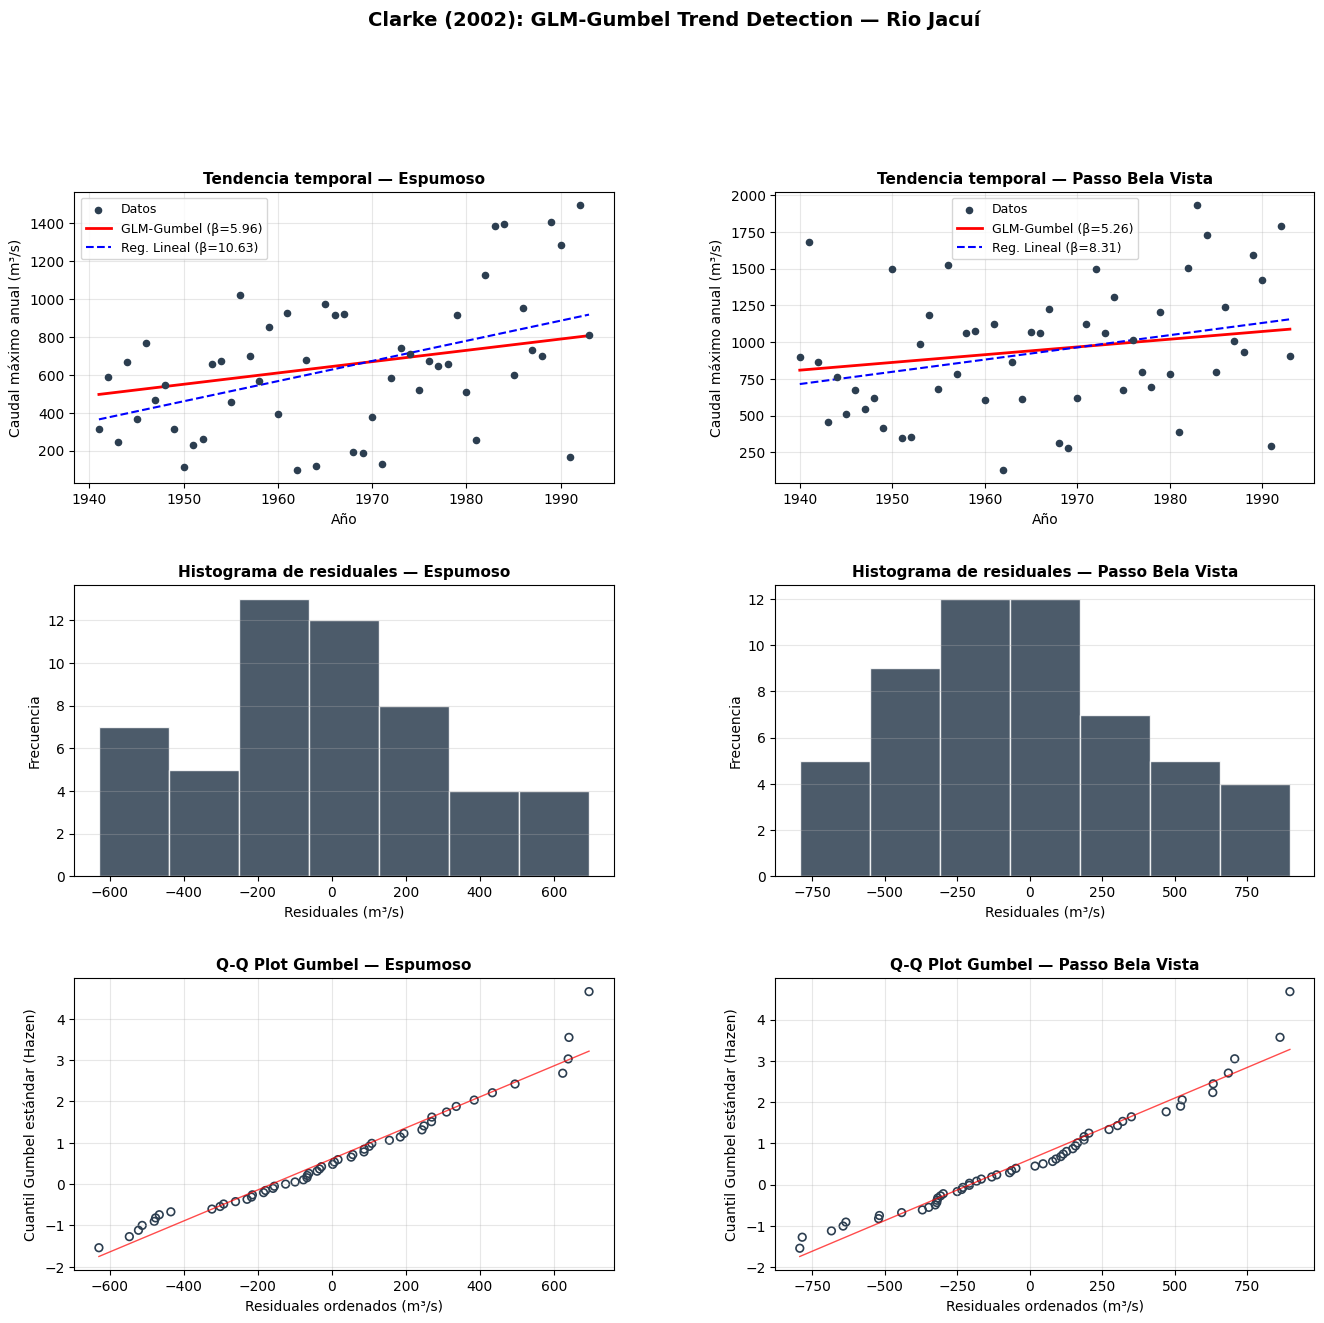

In [19]:
# =============================================================================
# 7. EJECUCIÓN PRINCIPAL
# =============================================================================

if __name__ == '__main__':

    print("\n" + "=" * 72)
    print("  ESTACIÓN: ESPUMOSO — Rio Jacuí, Brasil")
    print("=" * 72)
    res_esp = clarke_glm_gumbel(flows_espumoso, years_espumoso)
    lr_esp = linear_regression_trend(flows_espumoso, years_espumoso)
    mk_esp = mann_kendall_test(flows_espumoso)

    print(f"\n  --- Comparación con Regresión Lineal ---")
    print(f"  LR: β = {lr_esp['beta']:.2f} ± {lr_esp['se_beta']:.2f} "
          f"m³/s/año")
    print(f"  LR: R² = {lr_esp['R2'] * 100:.1f}%")
    print(f"  LR: p-value = {lr_esp['p_value']:.6f}")

    print(f"\n  --- Mann-Kendall ---")
    print(f"  Z = {mk_esp['Z']:.3f}, p-value = {mk_esp['p_value']:.6f}")

    print("\n\n" + "=" * 72)
    print("  ESTACIÓN: PASSO BELA VISTA — Rio Jacuí, Brasil")
    print("=" * 72)
    res_bv = clarke_glm_gumbel(flows_belavista, years_belavista)
    lr_bv = linear_regression_trend(flows_belavista, years_belavista)
    mk_bv = mann_kendall_test(flows_belavista)

    print(f"\n  --- Comparación con Regresión Lineal ---")
    print(f"  LR: β = {lr_bv['beta']:.2f} ± {lr_bv['se_beta']:.2f} "
          f"m³/s/año")
    print(f"  LR: R² = {lr_bv['R2'] * 100:.1f}%")
    print(f"  LR: p-value = {lr_bv['p_value']:.6f}")

    print(f"\n  --- Mann-Kendall ---")
    print(f"  Z = {mk_bv['Z']:.3f}, p-value = {mk_bv['p_value']:.6f}")

    # ---- Gráficas ----
    fig = plt.figure(figsize=(16, 14))
    gs = gridspec.GridSpec(3, 2, hspace=0.35, wspace=0.3)

    # Tendencias
    ax1 = fig.add_subplot(gs[0, 0])
    plot_trend(res_esp, lr_esp, 'Espumoso', ax1)
    ax2 = fig.add_subplot(gs[0, 1])
    plot_trend(res_bv, lr_bv, 'Passo Bela Vista', ax2)

    # Histogramas
    ax3 = fig.add_subplot(gs[1, 0])
    ax5 = fig.add_subplot(gs[2, 0])
    plot_gumbel_diagnostics(res_esp, 'Espumoso', ax3, ax5)

    ax4 = fig.add_subplot(gs[1, 1])
    ax6 = fig.add_subplot(gs[2, 1])
    plot_gumbel_diagnostics(res_bv, 'Passo Bela Vista', ax4, ax6)

    plt.suptitle('Clarke (2002): GLM-Gumbel Trend Detection — Rio Jacuí',
                 fontsize=14, fontweight='bold', y=1.01)
    plt.savefig('/home/Tarea_/clarke2002_results.png', dpi=150,
                bbox_inches='tight')
    print("\n\nFigura guardada: clarke2002_results.png")

    # ---- Tabla de convergencia (Tabla 2) ----
    print("\n\n" + "=" * 72)
    print("TABLA 2: Convergencia del algoritmo IWLS")
    print("=" * 72)
    print(f"\n{'':>4s}  {'--- Espumoso ---':^36s}  {'--- Passo Bela Vista ---':^36s}")
    print(f"{'Iter':>4s}  {'α̂':>10s}  {'m̂':>10s}  {'β̂':>10s}  "
          f"{'α̂':>10s}  {'m̂':>10s}  {'β̂':>10s}")
    print("-" * 72)

    max_rows = max(len(res_esp['history']), len(res_bv['history']))
    for i in range(max_rows):
        if i < len(res_esp['history']):
            he = res_esp['history'][i]
            e_str = f"{he['alpha']:>10.6f}  {he['m']:>10.2f}  {he['beta']:>10.4f}"
        else:
            e_str = f"{'':>10s}  {'':>10s}  {'':>10s}"

        if i < len(res_bv['history']):
            hb = res_bv['history'][i]
            b_str = f"{hb['alpha']:>10.6f}  {hb['m']:>10.2f}  {hb['beta']:>10.4f}"
        else:
            b_str = f"{'':>10s}  {'':>10s}  {'':>10s}"

        print(f"{i + 1:>4d}  {e_str}  {b_str}")

    print(f"{'ML':>4s}  {res_esp['alpha']:>10.6f}  {res_esp['m']:>10.2f}  "
          f"{res_esp['beta']:>10.4f}  "
          f"{res_bv['alpha']:>10.6f}  {res_bv['m']:>10.2f}  "
          f"{res_bv['beta']:>10.4f}")

    # ---- Simulación de potencia (reducida para velocidad) ----
    print("\n")
    sigma = np.pi / np.sqrt(6)
    table3, table4 = power_simulation(
        N_samples=100, N_size=50,
        beta_values=[0.0, 0.5 * sigma / 50, sigma / 50, 2 * sigma / 50],
        seed=42
    )

    plt.close('all')